# 03 Feature Engineering V2

Celem notebooka jest przygotowanie rozszerzonego zbioru cech dla modelu predykcji stężenia pyłu za elektrofiltem. Notebook bazuje na wcześniej przygotowanym zbiorze `df_model_clean_v1.parquet`, w którym wykonano mapowanie tagów, wybór zmiennej docelowej, klasyfikację sygnałów procesowych oraz czyszczenie braków danych.

Zmienną docelową modelu jest:

- `008A01345` — Pył BC1 Stężenie aktualne `[mg/Nm3]`

Do modelu wykorzystano sygnały wejściowe reprezentujące m.in.:

- parametry pracy elektrofiltru, takie jak napięcia, prądy, moce zespołów WN i częstotliwość przeskoków,
- statusy pracy strzepywaczy,
- temperatury lejów i rurociągów,
- parametry procesu spalania i przepływu spalin,
- obciążenie kotła/bloku,
- skład spalin, m.in. O2, CO, NOx, SO2 i wilgotność.

Głównym celem feature engineeringu jest uwzględnienie dynamicznego charakteru procesu odpylania, tzn. wpływu opóźnień, trendów krótkookresowych oraz zmian sygnałów procesowych na chwilowe stężenie pyłu.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

pd.set_option("display.max_columns", None)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

MODEL_CLEAN_PATH = DATA_PROCESSED / "df_model_clean_v1.parquet"

df_model_clean = pd.read_parquet(MODEL_CLEAN_PATH)

print(df_model_clean.shape)
df_model_clean.head()

(210644, 76)


,008A01345,008A00444,008A00936,008A00910,008A00911,008A00720,008A00728,008A02273,008A02274,008A02275,008A00719,008A00727,008A01350,008A01341,008A01343,008A01347,008A02118,016A00219,008A00723,016A00396,008A00731,008A01353,008B01474,008B01479,008B01484,008B01489,008A00741,008A00742,008B05167,008A02270,008A02292,008B05155,008A02267,008A02289,008A02264,008B05146,008B05131,008B05140,008A02276,008A02277,008B05100,008B05103,008A02282,008A02283,008B05173,008A02271,008A02293,008A02268,008A02290,008A02265,008B05150,008B05135,008A02278,008B05106,008A02284,008A02279,008B05109,008A02285,008B05178,008A02272,008A02294,008A02269,008A02291,008A02266,008B05154,008B05139,008A02280,008B05112,008A02286,008A02281,008B05115,008A02287,008B05096,008B05121,008B05126,008B05117
timestamp,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-06-30 00:00:00,11.0,186.0,32.500000,68282.0,73877.0,124.0,126.0,14.0,12.1,11.2,-0.63,-0.55,8.4,1315.0,174.0,46.0,4.9,137.0,13.0,149.0,14.0,146.0,0.0,0.0,0.0,0.0,5.1,8.9,1.0,266.0,390.0,1.0,296.0,47.0,0.0,0.0,0.0,1.0,103.0,83.0,0.0,0.0,91.0,86.0,1.0,212.0,392.0,306.0,39.0,0.0,0.0,0.0,88.0,0.0,47.0,70.0,1.0,44.0,1.0,212.0,388.0,304.0,37.0,0.0,0.0,0.0,49.0,1.0,37.0,88.0,0.0,32.0,1.0,1.0,1.0,1.0
2025-06-30 00:00:10,11.0,186.0,31.700001,68103.0,73804.0,124.0,126.0,14.0,12.1,11.2,-0.63,-0.55,8.4,1315.0,174.0,46.0,4.9,137.0,13.0,149.0,13.0,146.0,0.0,0.0,0.0,0.0,5.1,9.0,1.0,266.0,391.0,1.0,296.0,47.0,0.0,0.0,0.0,1.0,103.0,83.0,0.0,0.0,91.0,86.0,1.0,211.0,393.0,306.0,39.0,0.0,0.0,0.0,88.0,0.0,47.0,70.0,1.0,44.0,1.0,214.0,388.0,301.0,37.0,0.0,0.0,0.0,49.0,1.0,37.0,88.0,0.0,32.0,1.0,1.0,1.0,1.0
2025-06-30 00:00:20,11.0,186.0,32.000000,68766.0,73499.0,124.0,126.0,14.0,12.1,11.3,-0.63,-0.55,8.2,1308.0,174.0,44.0,4.9,136.0,13.0,149.0,13.0,151.0,0.0,0.0,0.0,0.0,5.1,9.1,1.0,267.0,391.0,1.0,296.0,47.0,0.0,0.0,0.0,1.0,103.0,83.0,0.0,0.0,92.0,86.0,1.0,214.0,391.0,306.0,39.0,0.0,0.0,0.0,88.0,0.0,47.0,70.0,1.0,44.0,1.0,217.0,385.0,304.0,37.0,0.0,0.0,0.0,49.0,1.0,37.0,88.0,0.0,32.0,1.0,1.0,1.0,1.0
2025-06-30 00:00:30,11.0,186.0,31.799999,68103.0,73645.0,124.0,126.0,13.8,11.8,11.2,-0.63,-0.55,8.2,1308.0,174.0,44.0,4.9,136.0,13.0,149.0,14.0,151.0,0.0,0.0,0.0,0.0,5.2,9.0,1.0,266.0,389.0,1.0,294.0,47.0,0.0,0.0,0.0,1.0,103.0,83.0,0.0,0.0,92.0,87.0,1.0,209.0,393.0,301.0,39.0,0.0,0.0,0.0,88.0,1.0,47.0,70.0,1.0,44.0,1.0,214.0,386.0,304.0,37.0,0.0,0.0,0.0,49.0,1.0,37.0,88.0,0.0,32.0,1.0,1.0,1.0,1.0
2025-06-30 00:00:40,9.0,186.0,32.400002,68209.0,73645.0,125.0,126.0,14.0,11.9,11.2,-0.63,-0.54,8.2,1313.0,173.0,45.0,4.9,136.0,13.0,149.0,14.0,150.0,0.0,0.0,0.0,0.0,5.2,9.1,1.0,269.0,389.0,1.0,296.0,47.0,0.0,0.0,0.0,1.0,103.0,83.0,0.0,0.0,92.0,87.0,1.0,207.0,394.0,301.0,39.0,0.0,0.0,0.0,88.0,1.0,47.0,70.0,1.0,44.0,1.0,209.0,386.0,304.0,37.0,0.0,0.0,0.0,49.0,1.0,37.0,87.0,0.0,32.0,1.0,1.0,1.0,1.0


In [2]:
print(type(df_model_clean.index))
print(df_model_clean.index.min())
print(df_model_clean.index.max())

df_model_clean.isna().sum().sum()

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>
2025-06-30 00:00:00
2025-08-01 00:00:00


np.int64(0)

## 1. Wczytanie przygotowanego zbioru danych

Wczytano wcześniej przygotowany zbiór `df_model_clean_v1.parquet`. Zbiór ten zawiera oczyszczone dane procesowe bez braków danych, obejmujące zmienną docelową oraz wybrane sygnały wejściowe.

Na tym etapie sprawdzono:

- rozmiar zbioru danych,
- zakres czasowy danych,
- typ indeksu czasowego,
- brak wartości `NaN`.

Indeks danych ma postać `DatetimeIndex`, co umożliwia dalszą analizę szeregu czasowego oraz tworzenie cech opóźnionych i kroczących.

In [3]:
time_diff_clean = df_model_clean.index.to_series().diff()

print("Najczęstsze odstępy czasu:")
print(time_diff_clean.value_counts().head(10))

print("\nNajwiększe przerwy:")
print(time_diff_clean.sort_values(ascending=False).head(10))

Najczęstsze odstępy czasu:
timestamp
0 days 00:00:10    210637
0 days 19:57:30         1
2 days 01:05:20         1
2 days 07:27:20         1
2 days 09:47:10         1
0 days 00:06:20         1
0 days 00:30:10         1
Name: count, dtype: int64

Największe przerwy:
timestamp
2025-07-20 00:00:00   2 days 09:47:10
2025-07-15 00:00:00   2 days 07:27:20
2025-07-06 00:00:00   2 days 01:05:20
2025-07-02 07:35:00   0 days 19:57:30
2025-07-26 10:26:30   0 days 00:30:10
2025-07-21 11:27:50   0 days 00:06:20
2025-07-23 20:30:10   0 days 00:00:10
2025-07-23 20:28:10   0 days 00:00:10
2025-07-23 20:27:10   0 days 00:00:10
2025-07-23 20:27:20   0 days 00:00:10
Name: timestamp, dtype: timedelta64[ns]


## 2. Analiza regularności próbkowania

Sprawdzono odstępy czasowe pomiędzy kolejnymi próbkami. Zdecydowana większość próbek była rejestrowana co 10 sekund. W danych występowały jednak dłuższe przerwy wynikające z wcześniejszego usunięcia fragmentów z brakującymi wartościami oraz z przerw w dostępności danych.

Ponieważ zwykłe użycie funkcji `shift()` lub `rolling()` mogłoby sztucznie łączyć próbki oddzielone dużą przerwą czasową, wprowadzono zmienną pomocniczą `segment_id`.

Każda przerwa większa niż 60 sekund rozpoczyna nowy segment danych. Dzięki temu cechy czasowe są wyznaczane oddzielnie w każdym ciągłym fragmencie szeregu czasowego.

In [4]:
# Tworzenie segmentów czasowych, aby nie łączyć danych przez duże przerwy

max_allowed_gap = pd.Timedelta(seconds=60)

time_diff_clean = df_model_clean.index.to_series().diff()

df_model_clean = df_model_clean.copy()
df_model_clean["segment_id"] = (time_diff_clean > max_allowed_gap).cumsum()

print("Liczba segmentów:", df_model_clean["segment_id"].nunique())

segment_summary = (
    df_model_clean
    .groupby("segment_id")
    .agg(
        start=("segment_id", lambda x: x.index.min()),
        end=("segment_id", lambda x: x.index.max()),
        n_samples=("segment_id", "size")
    )
)

segment_summary["duration"] = segment_summary["end"] - segment_summary["start"]

segment_summary

Liczba segmentów: 7


,start,end,n_samples,duration
segment_id,,,,
0,2025-06-30 00:00:00,2025-07-01 11:37:30,12826,1 days 11:37:30
1,2025-07-02 07:35:00,2025-07-03 22:54:40,14159,1 days 15:19:40
2,2025-07-06 00:00:00,2025-07-12 16:32:40,57797,6 days 16:32:40
3,2025-07-15 00:00:00,2025-07-17 14:12:50,22398,2 days 14:12:50
4,2025-07-20 00:00:00,2025-07-21 11:21:30,12730,1 days 11:21:30
5,2025-07-21 11:27:50,2025-07-26 09:56:20,42652,4 days 22:28:30
6,2025-07-26 10:26:30,2025-08-01 00:00:00,48082,5 days 13:33:30


In [5]:
target_col = "008A01345"  # Pył BC1 Stężenie aktualne

input_cols = [
    col for col in df_model_clean.columns
    if col not in [target_col, "segment_id"]
]

print("Target:", target_col)
print("Number of input columns:", len(input_cols))
print(input_cols[:10])

Target: 008A01345
Number of input columns: 75
['008A00444', '008A00936', '008A00910', '008A00911', '008A00720', '008A00728', '008A02273', '008A02274', '008A02275', '008A00719']


In [6]:
target_col in input_cols

False

## 3. Segmentacja szeregu czasowego

Dane zostały podzielone na 7 ciągłych segmentów czasowych. Segmentacja została wykorzystana wyłącznie technicznie do poprawnego obliczania cech opóźnionych, średnich kroczących i różnic sygnałów.

Zmienna `segment_id` nie jest traktowana jako właściwa cecha procesu. Przed treningiem modelu została usunięta ze zbioru wejściowego, aby model nie uczył się specyfiki konkretnego fragmentu czasowego zamiast zależności procesowych.

## 4. Cechy opóźnione — lag features

W pierwszym etapie feature engineeringu utworzono cechy opóźnione dla wszystkich sygnałów wejściowych. Cechy te pozwalają modelowi uwzględnić wpływ wcześniejszych wartości zmiennych procesowych na aktualne stężenie pyłu.

Zastosowano następujące opóźnienia:

| Lag | Odpowiednik czasowy |
|---:|---:|
| 1 | 10 s |
| 3 | 30 s |
| 6 | 1 min |
| 12 | 2 min |
| 30 | 5 min |
| 60 | 10 min |
| 180 | 30 min |

Cechy opóźnione zostały obliczone osobno wewnątrz każdego segmentu czasowego, aby uniknąć przenoszenia informacji przez dłuższe przerwy w danych.

In [8]:
lags = [1, 3, 6, 12, 30, 60, 180]

lag_features = []

for lag in lags:
    lag_df = (
        df_model_clean
        .groupby("segment_id")[input_cols]
        .shift(lag)
    )
    
    lag_df.columns = [f"{col}_lag_{lag}" for col in input_cols]
    lag_features.append(lag_df)

df_fe = pd.concat(
    [df_model_clean] + lag_features,
    axis=1
)

# defragmentacja pamięci
df_fe = df_fe.copy()

print("Before lag features:", df_model_clean.shape)
print("After lag features:", df_fe.shape)

Before lag features: (210644, 77)
After lag features: (210644, 602)


In [9]:
lag_missing = df_fe.isna().sum().sort_values(ascending=False)
lag_missing[lag_missing > 0].head(20)

008A02276_lag_180    1260
008B05117_lag_180    1260
008B05126_lag_180    1260
008B05121_lag_180    1260
008B05096_lag_180    1260
008A02287_lag_180    1260
008B05115_lag_180    1260
008A02281_lag_180    1260
008A02286_lag_180    1260
008B05112_lag_180    1260
008A02280_lag_180    1260
008B05139_lag_180    1260
008B05154_lag_180    1260
008A02266_lag_180    1260
008B01479_lag_180    1260
008B01484_lag_180    1260
008B01489_lag_180    1260
008A00741_lag_180    1260
008A00742_lag_180    1260
008B05167_lag_180    1260
dtype: int64

Po utworzeniu cech opóźnionych liczba kolumn wzrosła z 77 do 602. Liczba braków w cechach opóźnionych wynikała z początku każdego segmentu czasowego, gdzie nie jest dostępna historia wymagana do obliczenia danego opóźnienia.

Dla opóźnienia `lag_180` liczba braków wynosiła 1260, co odpowiada:

`7 segmentów × 180 próbek = 1260`

Jest to oczekiwane zachowanie i potwierdza, że cechy opóźnione zostały obliczone poprawnie wewnątrz segmentów.

In [12]:
TAG_CLASSIFICATION_PATH = DATA_PROCESSED / "tag_classification_v1.xlsx"

classified = pd.read_excel(TAG_CLASSIFICATION_PATH)

print(classified.shape)
classified.head()

(76, 7)


,tag,description,symbol,unit,category,role,comment
0,008A00444,T wody zasilającej przed kotłem,08_T_WO_KOT,stC,boiler_water_temperature,input,temperatura wody zasilającej
1,008A00936,N Czynna Generatora Kanal 1,08_TU_MOCCZYNNGENK1,MW,boiler_load,input,obciążenie bloku/kotła/generatora
2,008A00910,F pow.do kotła Z/L,08_F_POWDOKOTL_Z_L,Nm3/h,boiler_air_flow,input,przepływ powietrza do kotła
3,008A00911,F pow.do kotła Z/P,08_F_POWDOKOTL_Z_P,Nm3/h,boiler_air_flow,input,przepływ powietrza do kotła
4,008A00720,T spalin za podgrz. pow. OPP str.L,08_P_SPAPRZEZDELF_L,stC,flue_gas_temperature,input,temperatura spalin


## 5. Cechy kroczące — rolling features

W kolejnym etapie utworzono cechy kroczące dla sygnałów ciągłych. Do tej grupy zaliczono sygnały posiadające więcej niż 10 unikalnych wartości, co pozwoliło odróżnić zmienne analogowe od statusów binarnych lub dyskretnych.

Dla sygnałów ciągłych obliczono:

- średnią kroczącą,
- odchylenie standardowe kroczące.

Zastosowano następujące okna czasowe:

| Okno | Odpowiednik czasowy |
|---:|---:|
| 6 | 1 min |
| 30 | 5 min |
| 60 | 10 min |
| 180 | 30 min |

Cechy kroczące pozwalają modelowi uwzględnić nie tylko wartości chwilowe, ale również poziom i zmienność sygnałów w krótkich i średnich horyzontach czasowych.

In [13]:
# Rolling features tylko dla sygnałów ciągłych / analogowych

continuous_input_cols = [
    col for col in input_cols
    if df_model_clean[col].nunique(dropna=True) > 10
]

print("Liczba sygnałów ciągłych:", len(continuous_input_cols))
continuous_input_cols = [
    col for col in input_cols
    if df_model_clean[col].nunique(dropna=True) > 10
]

continuous_summary = classified[
    classified["tag"].isin(continuous_input_cols)
][["tag", "description", "symbol", "unit", "category"]].copy()

continuous_summary["n_unique"] = continuous_summary["tag"].apply(
    lambda col: df_model_clean[col].nunique(dropna=True)
)

continuous_summary["min"] = continuous_summary["tag"].apply(
    lambda col: df_model_clean[col].min()
)

continuous_summary["max"] = continuous_summary["tag"].apply(
    lambda col: df_model_clean[col].max()
)

continuous_summary = continuous_summary.sort_values(["category", "tag"]).reset_index(drop=True)

print("Liczba sygnałów ciągłych:", len(continuous_input_cols))
continuous_summary

Liczba sygnałów ciągłych: 47
Liczba sygnałów ciągłych: 47


,tag,description,symbol,unit,category,n_unique,min,max
0,008A00723,G kierownic WS1,08_SO_KIER_WS1,%,boiler_air_damper,20,11.0,30.000000
1,008A00731,G kierownic WS2,08_SO_KIER_WS2,%,boiler_air_damper,20,11.0,30.000000
2,008A00910,F pow.do kotła Z/L,08_F_POWDOKOTL_Z_L,Nm3/h,boiler_air_flow,2674,47811.0,95903.000000
3,008A00911,F pow.do kotła Z/P,08_F_POWDOKOTL_Z_P,Nm3/h,boiler_air_flow,2023,62280.0,100350.000000
4,008A00936,N Czynna Generatora Kanal 1,08_TU_MOCCZYNNGENK1,MW,boiler_load,258,20.1,48.599998
5,016A00219,R1 P13 Moc czynna całkowita,16_R1P13PECA_PCZ,kW,boiler_load,73,119.0,191.000000
6,016A00396,R1 P18 Moc czynna całkowita,16_R1P18PECA_PCZ,kW,boiler_load,63,133.0,196.000000
7,008A00444,T wody zasilającej przed kotłem,08_T_WO_KOT,stC,boiler_water_temperature,50,127.0,204.000000
8,008A02267,Zespół Zasil WN str 1A PRĄD WTÓRNY,08_IWT_WN_1A,mADC,esp_current,212,171.0,1519.000000
9,008A02268,Zespół Zasil WN str 2A PRĄD WTÓRNY,08_IWT_WN_2A,mADC,esp_current,129,107.0,1561.000000


In [14]:
windows = [6, 30, 60, 180]

rolling_features = []

for window in windows:
    roll_mean = (
        df_model_clean
        .groupby("segment_id")[continuous_input_cols]
        .rolling(window=window, min_periods=window)
        .mean()
        .reset_index(level=0, drop=True)
    )
    roll_mean.columns = [
        f"{col}_roll_mean_{window}" for col in continuous_input_cols
    ]

    roll_std = (
        df_model_clean
        .groupby("segment_id")[continuous_input_cols]
        .rolling(window=window, min_periods=window)
        .std()
        .reset_index(level=0, drop=True)
    )
    roll_std.columns = [
        f"{col}_roll_std_{window}" for col in continuous_input_cols
    ]

    rolling_features.extend([roll_mean, roll_std])

df_fe = pd.concat(
    [df_fe] + rolling_features,
    axis=1
)

df_fe = df_fe.copy()

print("After rolling features:", df_fe.shape)

After rolling features: (210644, 978)


In [15]:
rolling_missing = df_fe.isna().sum().sort_values(ascending=False)
rolling_missing[rolling_missing > 0].head(20)

008A00720_lag_180    1260
008A00936_lag_180    1260
008A00910_lag_180    1260
008A00911_lag_180    1260
008A00444_lag_180    1260
008A02278_lag_180    1260
008B05106_lag_180    1260
008A02284_lag_180    1260
008A02279_lag_180    1260
008A02266_lag_180    1260
008A02281_lag_180    1260
008A02291_lag_180    1260
008A02294_lag_180    1260
008A02269_lag_180    1260
008B05117_lag_180    1260
008B05112_lag_180    1260
008A02286_lag_180    1260
008A02280_lag_180    1260
008B05139_lag_180    1260
008B05154_lag_180    1260
dtype: int64

In [16]:
rolling_cols = [col for col in df_fe.columns if "roll_" in col]

print("Liczba rolling features:", len(rolling_cols))
print(rolling_cols[:20])

Liczba rolling features: 376
['008A00444_roll_mean_6', '008A00936_roll_mean_6', '008A00910_roll_mean_6', '008A00911_roll_mean_6', '008A00720_roll_mean_6', '008A00728_roll_mean_6', '008A02273_roll_mean_6', '008A02274_roll_mean_6', '008A02275_roll_mean_6', '008A00719_roll_mean_6', '008A00727_roll_mean_6', '008A01350_roll_mean_6', '008A01341_roll_mean_6', '008A01343_roll_mean_6', '008A01347_roll_mean_6', '008A02118_roll_mean_6', '016A00219_roll_mean_6', '008A00723_roll_mean_6', '016A00396_roll_mean_6', '008A00731_roll_mean_6']


In [17]:
rolling_missing_only = df_fe[rolling_cols].isna().sum().sort_values(ascending=False)

rolling_missing_only.head(20)

008A02287_roll_std_180     1253
008A02286_roll_std_180     1253
008A02280_roll_std_180     1253
008A02291_roll_std_180     1253
008A02269_roll_std_180     1253
008A02294_roll_std_180     1253
008A02272_roll_std_180     1253
008A02285_roll_std_180     1253
008A02279_roll_std_180     1253
008A02284_roll_std_180     1253
008A02278_roll_std_180     1253
008A02290_roll_std_180     1253
008A02269_roll_mean_180    1253
008A02291_roll_mean_180    1253
008A02280_roll_mean_180    1253
008A02286_roll_mean_180    1253
008A02287_roll_mean_180    1253
008A00444_roll_std_180     1253
008A00936_roll_std_180     1253
008A00910_roll_std_180     1253
dtype: int64

Rolling features utworzono dla 47 zmiennych ciągłych. Dla każdej zmiennej obliczono średnią i odchylenie standardowe w czterech oknach czasowych, co dało:

`47 zmiennych × 4 okna × 2 statystyki = 376 nowych cech`

Cechy te opisują lokalny stan procesu, jego stabilność oraz zmienność w horyzontach od 1 do 30 minut.

## 6. Cechy różnicowe — diff features

W celu uchwycenia dynamiki zmian procesu utworzono cechy różnicowe dla sygnałów ciągłych. Cechy te opisują zmianę wartości sygnału względem wcześniejszego punktu czasowego.

Zastosowano następujące okresy różnicowania:

| Diff | Odpowiednik czasowy |
|---:|---:|
| 1 | 10 s |
| 6 | 1 min |
| 30 | 5 min |
| 60 | 10 min |

Cechy różnicowe są szczególnie istotne w kontekście elektrofiltru, ponieważ szybkie zmiany prądu, napięcia, mocy zespołów WN, parametrów spalania lub przepływu spalin mogą poprzedzać zmiany stężenia pyłu.

In [18]:
diff_periods = [1, 6, 30, 60]

diff_features = []

for period in diff_periods:
    diff_df = (
        df_model_clean
        .groupby("segment_id")[continuous_input_cols]
        .diff(periods=period)
    )
    
    diff_df.columns = [
        f"{col}_diff_{period}" for col in continuous_input_cols
    ]
    
    diff_features.append(diff_df)

df_fe = pd.concat(
    [df_fe] + diff_features,
    axis=1
)

df_fe = df_fe.copy()

print("After diff features:", df_fe.shape)

After diff features: (210644, 1166)


In [19]:
print("Before final dropna:", df_fe.shape)

df_fe_clean = df_fe.dropna().copy()

print("After final dropna:", df_fe_clean.shape)
print("Removed rows:", len(df_fe) - len(df_fe_clean))
print("Removed percent:", round((len(df_fe) - len(df_fe_clean)) / len(df_fe) * 100, 3), "%")

Before final dropna: (210644, 1166)
After final dropna: (209384, 1166)
Removed rows: 1260
Removed percent: 0.598 %


In [20]:
df_fe_clean.isna().sum().sum()

np.int64(0)

In [21]:
target_col = "008A01345"

X = df_fe_clean.drop(columns=[target_col])
y = df_fe_clean[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (209384, 1165)
y shape: (209384,)


In [22]:
target_col = "008A01345"

cols_to_drop_from_X = [
    target_col,
    "segment_id"
]

X = df_fe_clean.drop(columns=cols_to_drop_from_X)
y = df_fe_clean[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("segment_id in X:", "segment_id" in X.columns)

X shape: (209384, 1164)
y shape: (209384,)
segment_id in X: False


## 7. Końcowe czyszczenie zbioru po feature engineeringu

Po utworzeniu cech opóźnionych, kroczących i różnicowych usunięto wiersze zawierające wartości `NaN`. Braki te wynikały naturalnie z tworzenia cech historycznych na początku każdego segmentu czasowego.

Po końcowym czyszczeniu zbiór zawierał:

- `209384` próbki,
- `1165` cech wejściowych przed usunięciem zmiennej technicznej,
- brak wartości `NaN`.

Ze zbioru wejściowego usunięto `segment_id`, ponieważ jest to zmienna techniczna, a nie rzeczywista cecha procesu.

In [23]:
split_idx = int(len(df_fe_clean) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

print("Train period:", X_train.index.min(), "->", X_train.index.max())
print("Test period:", X_test.index.min(), "->", X_test.index.max())

Train: (167507, 1164) (167507,)
Test: (41877, 1164) (41877,)
Train period: 2025-06-30 00:30:00 -> 2025-07-27 03:40:30
Test period: 2025-07-27 03:40:40 -> 2025-08-01 00:00:00


## 8. Trening modelu XGBoost

Do oceny wpływu feature engineeringu wykorzystano model `XGBRegressor`. Dane podzielono chronologicznie na zbiór treningowy i testowy w proporcji 80/20. Nie stosowano losowego mieszania próbek, ponieważ dane mają charakter szeregu czasowego.

Model trenowano na pełnym zestawie cech obejmującym:

- wartości chwilowe sygnałów,
- cechy opóźnione,
- średnie i odchylenia standardowe kroczące,
- cechy różnicowe.

Celem eksperymentu było sprawdzenie, czy uwzględnienie historii i dynamiki sygnałów poprawia predykcję stężenia pyłu względem wcześniejszego modelu bazowego.

In [24]:
model_fe = XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

model_fe.fit(X_train, y_train)

y_pred = model_fe.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.3f}")
print(f"R2: {r2:.3f}")

MAE: 1.393
R2: 0.723


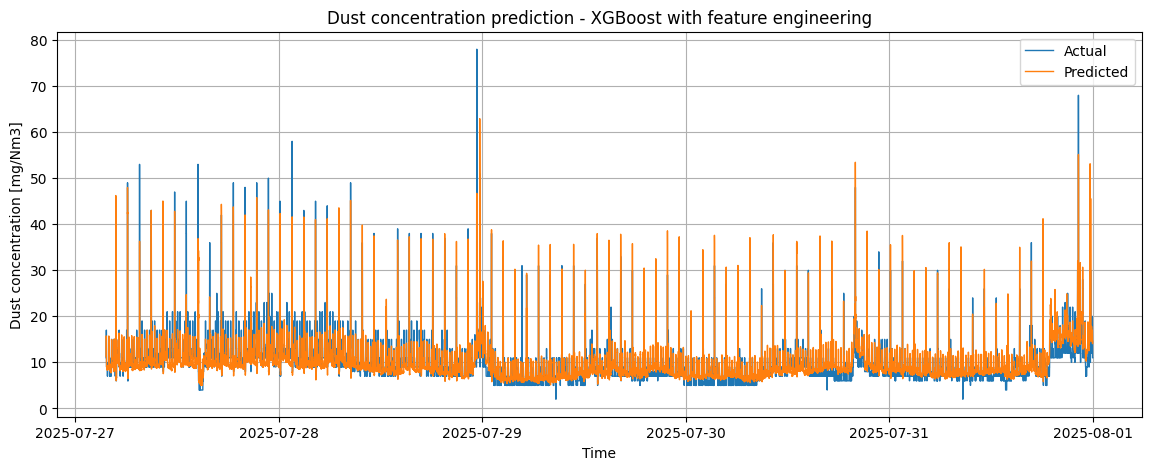

In [25]:
plt.figure(figsize=(14, 5))
plt.plot(y_test.index, y_test.values, label="Actual", linewidth=1)
plt.plot(y_test.index, y_pred, label="Predicted", linewidth=1)

plt.title("Dust concentration prediction - XGBoost with feature engineering")
plt.xlabel("Time")
plt.ylabel("Dust concentration [mg/Nm3]")
plt.legend()
plt.grid(True)
plt.show()

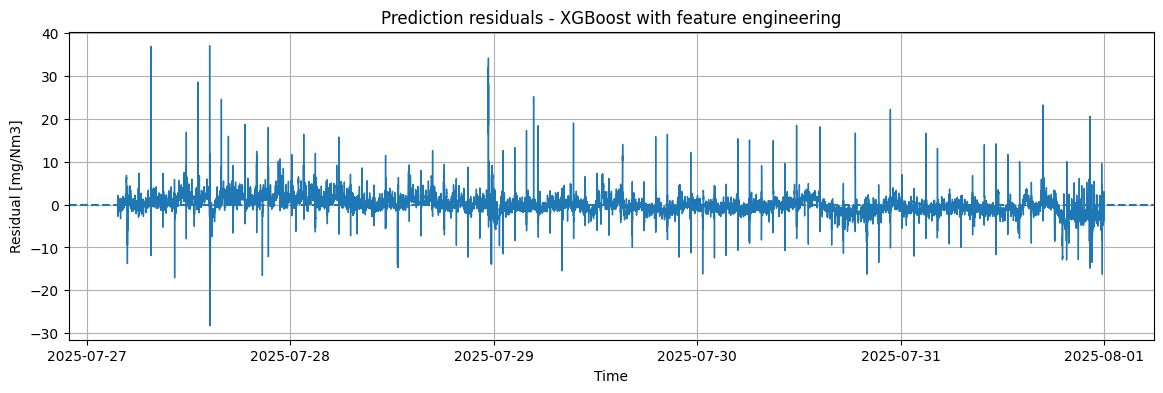

In [26]:
residuals = y_test - y_pred

plt.figure(figsize=(14, 4))
plt.plot(y_test.index, residuals, linewidth=1)
plt.axhline(0, linestyle="--")
plt.title("Prediction residuals - XGBoost with feature engineering")
plt.xlabel("Time")
plt.ylabel("Residual [mg/Nm3]")
plt.grid(True)
plt.show()

## 9. Wyniki modelu po feature engineeringu

Model z pełnym zestawem cech po feature engineeringu osiągnął:

- `MAE = 1.393 mg/Nm3`,
- `R2 = 0.723`.

W porównaniu z wcześniejszym modelem bazowym:

- `MAE = 1.34 mg/Nm3`,
- `R2 = 0.660`.

Wynik wskazuje, że feature engineering poprawił zdolność modelu do wyjaśniania zmienności stężenia pyłu, co widać po wzroście współczynnika `R2`. Jednocześnie średni błąd bezwzględny nie uległ poprawie, co sugeruje, że model lepiej odtwarza dynamikę procesu, ale może generować bardziej zmienne predykcje.

In [27]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model_fe.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance.head(30)

,feature,importance
1031,008A02275_diff_6,0.062032
1065,008A02269_diff_6,0.060519
710,016A00219_roll_mean_30,0.027881
901,008A00731_roll_mean_180,0.018257
166,016A00219_lag_3,0.016349
1057,008A02268_diff_6,0.015003
241,016A00219_lag_6,0.014564
1054,008A02283_diff_6,0.012948
678,008A02283_roll_std_6,0.012655
363,008B05154_lag_12,0.012622


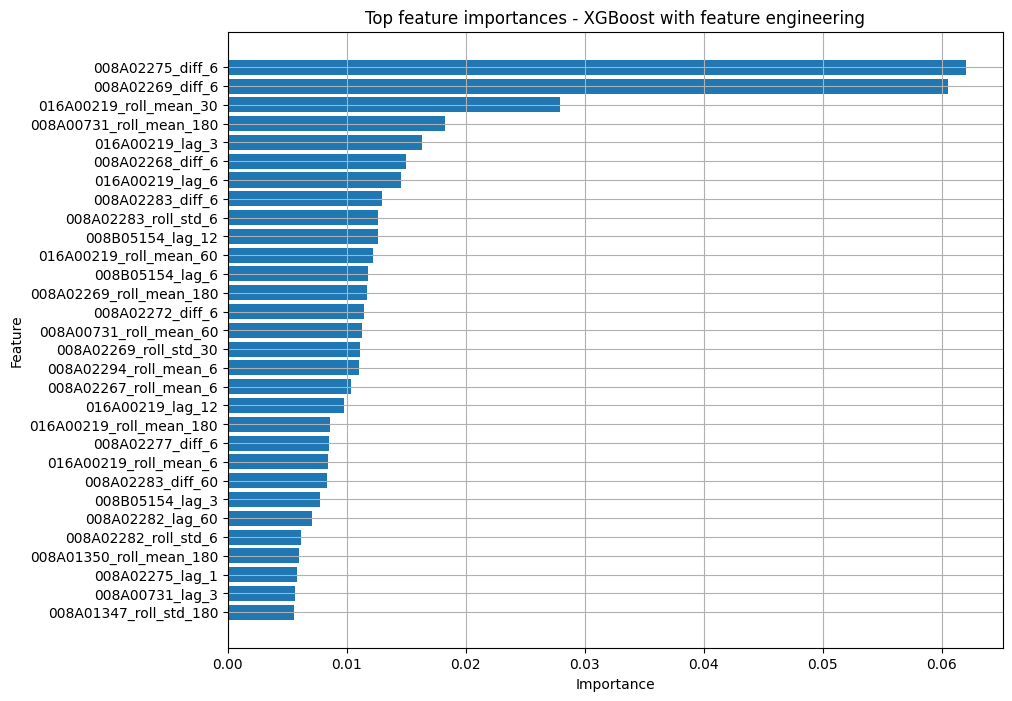

In [28]:
top_n = 30

plt.figure(figsize=(10, 8))
plt.barh(
    feature_importance.head(top_n)["feature"][::-1],
    feature_importance.head(top_n)["importance"][::-1]
)
plt.title("Top feature importances - XGBoost with feature engineering")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.grid(True)
plt.show()

In [29]:
def split_feature_name(feature_name):
    """
    Rozdziela nazwę cechy na bazowy tag i typ transformacji.
    Przykłady:
    008A02275_diff_6 -> base_tag=008A02275, transform=diff_6
    016A00219_roll_mean_30 -> base_tag=016A00219, transform=roll_mean_30
    008A02269_lag_6 -> base_tag=008A02269, transform=lag_6
    008A02275 -> base_tag=008A02275, transform=raw
    """
    parts = feature_name.split("_")

    base_tag = parts[0]

    if len(parts) == 1:
        transform = "raw"
    else:
        transform = "_".join(parts[1:])

    return base_tag, transform


feature_importance_readable = feature_importance.copy()

feature_importance_readable[["base_tag", "transform"]] = (
    feature_importance_readable["feature"]
    .apply(lambda x: pd.Series(split_feature_name(x)))
)

feature_importance_readable = feature_importance_readable.merge(
    classified[["tag", "description", "symbol", "unit", "category"]],
    left_on="base_tag",
    right_on="tag",
    how="left"
)

feature_importance_readable = feature_importance_readable[
    [
        "feature",
        "base_tag",
        "description",
        "symbol",
        "unit",
        "category",
        "transform",
        "importance"
    ]
]

feature_importance_readable.head(40)

,feature,base_tag,description,symbol,unit,category,transform,importance
0,008A02275_diff_6,008A02275,Zespół Zasil WN str 3A Moc Zespołu,08_NZ_WN_3A,kW,esp_power,diff_6,0.062032
1,008A02269_diff_6,008A02269,Zespół Zasil WN str 3A PRĄD WTÓRNY,08_IWT_WN_3A,mADC,esp_current,diff_6,0.060519
2,016A00219_roll_mean_30,016A00219,R1 P13 Moc czynna całkowita,16_R1P13PECA_PCZ,kW,boiler_load,roll_mean_30,0.027881
3,008A00731_roll_mean_180,008A00731,G kierownic WS2,08_SO_KIER_WS2,%,boiler_air_damper,roll_mean_180,0.018257
4,016A00219_lag_3,016A00219,R1 P13 Moc czynna całkowita,16_R1P13PECA_PCZ,kW,boiler_load,lag_3,0.016349
5,008A02268_diff_6,008A02268,Zespół Zasil WN str 2A PRĄD WTÓRNY,08_IWT_WN_2A,mADC,esp_current,diff_6,0.015003
6,016A00219_lag_6,016A00219,R1 P13 Moc czynna całkowita,16_R1P13PECA_PCZ,kW,boiler_load,lag_6,0.014564
7,008A02283_diff_6,008A02283,T rurociągu 1B,08_T_R1B,stC,esp_temperature,diff_6,0.012948
8,008A02283_roll_std_6,008A02283,T rurociągu 1B,08_T_R1B,stC,esp_temperature,roll_std_6,0.012655
9,008B05154_lag_12,008B05154,Strzep Elektrod zbior strefa 3 Potw Zał,08_ST_EL_ZB3_ZAL,NaN,esp_rapping,lag_12,0.012622


In [30]:
importance_by_signal = (
    feature_importance_readable
    .groupby(["base_tag", "description", "symbol", "unit", "category"], dropna=False)["importance"]
    .sum()
    .reset_index()
    .sort_values("importance", ascending=False)
)

importance_by_signal.head(30)

,base_tag,description,symbol,unit,category,importance
73,016A00219,R1 P13 Moc czynna całkowita,16_R1P13PECA_PCZ,kW,boiler_load,0.101075
29,008A02275,Zespół Zasil WN str 3A Moc Zespołu,08_NZ_WN_3A,kW,esp_power,0.098152
23,008A02269,Zespół Zasil WN str 3A PRĄD WTÓRNY,08_IWT_WN_3A,mADC,esp_current,0.095880
6,008A00731,G kierownic WS2,08_SO_KIER_WS2,%,boiler_air_damper,0.044899
37,008A02283,T rurociągu 1B,08_T_R1B,stC,esp_temperature,0.042254
36,008A02282,T rurociągu 1A,08_T_R1A,stC,esp_temperature,0.036036
68,008B05154,Strzep Elektrod zbior strefa 3 Potw Zał,08_ST_EL_ZB3_ZAL,NaN,esp_rapping,0.034479
14,008A01347,CO BC1 Steżenie aktualne,08_QP_CO_W,mg/Nm3,flue_gas_co,0.027807
22,008A02268,Zespół Zasil WN str 2A PRĄD WTÓRNY,08_IWT_WN_2A,mADC,esp_current,0.026419
17,008A02118,BC1 Wilgotność spalin,08_WLG_SPL_L,%,flue_gas_humidity,0.024454


## 10. Analiza ważności cech

Przeprowadzono analizę ważności cech modelu XGBoost. W pierwszym kroku ważności zostały przypisane do konkretnych cech, a następnie zagregowane według:

- oryginalnych sygnałów procesowych,
- kategorii sygnałów,
- typu transformacji cechy.

Analiza według sygnałów wykazała, że największe znaczenie miały m.in.:

- `016A00219` — R1 P13 Moc czynna całkowita,
- `008A02275` — Zespół Zasil WN str 3A Moc Zespołu,
- `008A02269` — Zespół Zasil WN str 3A Prąd wtórny,
- `008A00731` — położenie kierownic WS2,
- temperatury rurociągów i lejów.

Wynik ten wskazuje, że model wykorzystuje zarówno parametry pracy elektrofiltru, jak i zmienne opisujące obciążenie kotła oraz warunki procesu spalania.

In [31]:
importance_by_transform = (
    feature_importance_readable
    .groupby("transform")["importance"]
    .sum()
    .reset_index()
    .sort_values("importance", ascending=False)
)

importance_by_transform.head(30)

,transform,importance
2,diff_6,0.201719
12,roll_mean_180,0.102903
14,roll_mean_6,0.081527
9,lag_6,0.071618
13,roll_mean_30,0.070014
15,roll_mean_60,0.058085
7,lag_3,0.051913
5,lag_12,0.049009
11,raw,0.040215
17,roll_std_30,0.039118


In [32]:
importance_by_category = (
    feature_importance_readable
    .groupby("category", dropna=False)["importance"]
    .sum()
    .reset_index()
    .sort_values("importance", ascending=False)
)

importance_by_category

,category,importance
5,esp_current,0.192644
11,esp_temperature,0.186131
7,esp_power,0.124451
2,boiler_load,0.114740
12,esp_voltage,0.071795
0,boiler_air_damper,0.055075
17,flue_gas_o2,0.047557
8,esp_rapping,0.039105
1,boiler_air_flow,0.036523
13,flue_gas_co,0.027807


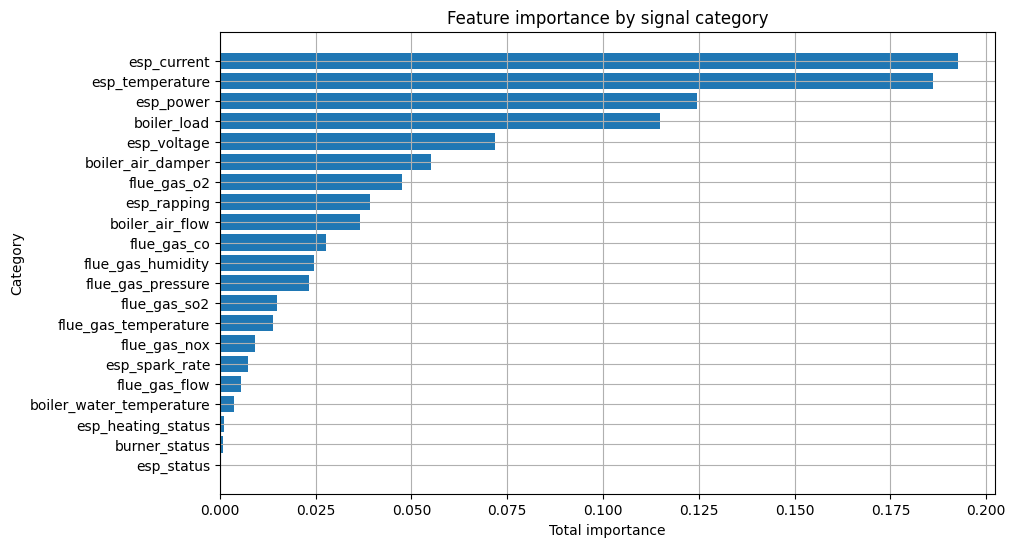

In [33]:
plt.figure(figsize=(10, 6))
plt.barh(
    importance_by_category["category"][::-1],
    importance_by_category["importance"][::-1]
)
plt.title("Feature importance by signal category")
plt.xlabel("Total importance")
plt.ylabel("Category")
plt.grid(True)
plt.show()

## 11. Ważność kategorii sygnałów

Agregacja ważności cech według kategorii wykazała, że największy wpływ na predykcję miały grupy:

- `esp_current`,
- `esp_temperature`,
- `esp_power`,
- `boiler_load`,
- `esp_voltage`.

Jest to zgodne z fizyczną interpretacją procesu. Prąd wtórny i moc zespołów WN opisują rzeczywisty stan pracy pola elektrostatycznego, natomiast obciążenie kotła i temperatury charakteryzują warunki procesu spalania oraz przepływu spalin.

Warto zauważyć, że prądy elektrofiltru okazały się ważniejsze niż same napięcia, co może oznaczać, że prąd wtórny lepiej odzwierciedla rzeczywistą intensywność wyładowania koronowego i skuteczność odpylania.

In [34]:
importance_by_transform = (
    feature_importance_readable
    .groupby("transform")["importance"]
    .sum()
    .reset_index()
    .sort_values("importance", ascending=False)
)

importance_by_transform

,transform,importance
2,diff_6,0.201719
12,roll_mean_180,0.102903
14,roll_mean_6,0.081527
9,lag_6,0.071618
13,roll_mean_30,0.070014
15,roll_mean_60,0.058085
7,lag_3,0.051913
5,lag_12,0.049009
11,raw,0.040215
17,roll_std_30,0.039118


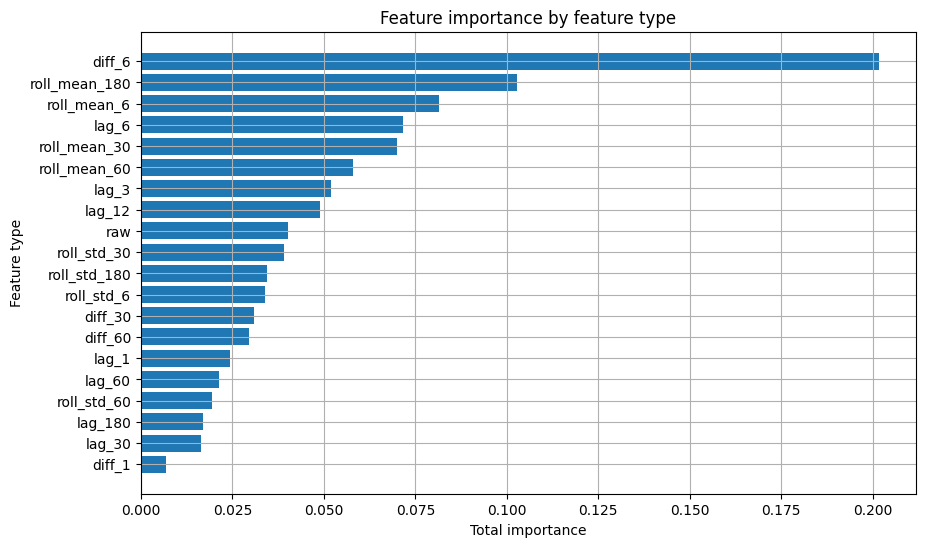

In [35]:
plt.figure(figsize=(10, 6))
plt.barh(
    importance_by_transform["transform"][::-1],
    importance_by_transform["importance"][::-1]
)
plt.title("Feature importance by feature type")
plt.xlabel("Total importance")
plt.ylabel("Feature type")
plt.grid(True)
plt.show()

## 12. Ważność typów cech

Analiza ważności według typu transformacji wykazała, że model w dużym stopniu korzysta z cech dynamicznych. Szczególnie istotne były:

- `diff_6` — zmiana sygnału w okresie około 1 minuty,
- `roll_mean_180` — średnia krocząca z około 30 minut,
- `roll_mean_6` — średnia krocząca z około 1 minuty,
- `lag_6` — wartość sygnału sprzed około 1 minuty,
- `roll_mean_30` i `roll_mean_60`.

Wynik ten wskazuje, że dla predykcji stężenia pyłu istotne są nie tylko wartości chwilowe, ale przede wszystkim historia i dynamika zmian parametrów procesu.

In [36]:
diff_cols = [col for col in X.columns if "_diff_" in col]

X_no_diff = X.drop(columns=diff_cols)

split_idx = int(len(X_no_diff) * 0.8)

X_train_no_diff = X_no_diff.iloc[:split_idx]
X_test_no_diff = X_no_diff.iloc[split_idx:]

y_train_no_diff = y.iloc[:split_idx]
y_test_no_diff = y.iloc[split_idx:]

print("X without diff:", X_no_diff.shape)

X without diff: (209384, 976)


In [37]:
model_no_diff = XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

model_no_diff.fit(X_train_no_diff, y_train_no_diff)

y_pred_no_diff = model_no_diff.predict(X_test_no_diff)

mae_no_diff = mean_absolute_error(y_test_no_diff, y_pred_no_diff)
r2_no_diff = r2_score(y_test_no_diff, y_pred_no_diff)

print(f"MAE no diff: {mae_no_diff:.3f}")
print(f"R2 no diff: {r2_no_diff:.3f}")

MAE no diff: 1.451
R2 no diff: 0.670


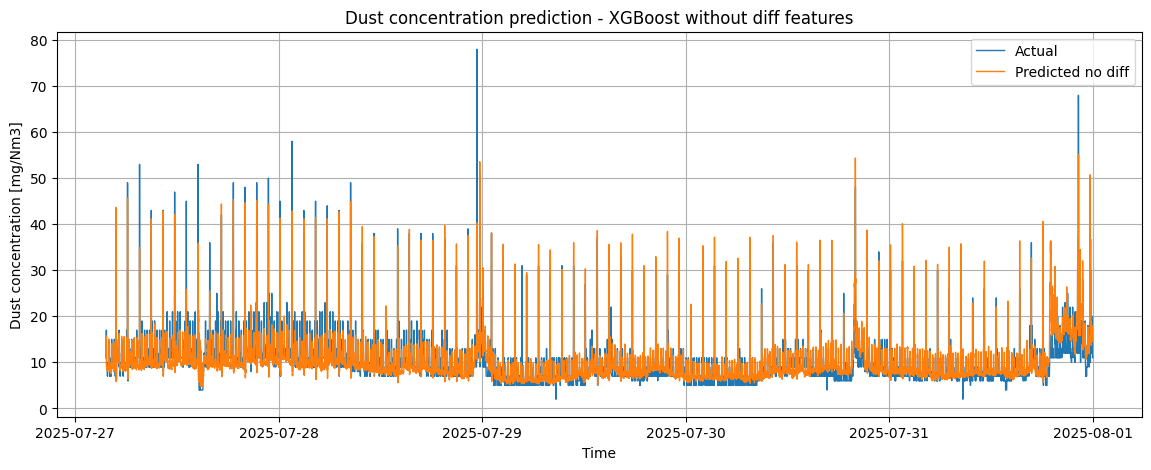

In [38]:
plt.figure(figsize=(14, 5))
plt.plot(y_test_no_diff.index, y_test_no_diff.values, label="Actual", linewidth=1)
plt.plot(y_test_no_diff.index, y_pred_no_diff, label="Predicted no diff", linewidth=1)

plt.title("Dust concentration prediction - XGBoost without diff features")
plt.xlabel("Time")
plt.ylabel("Dust concentration [mg/Nm3]")
plt.legend()
plt.grid(True)
plt.show()

In [39]:
diff_1_cols = [col for col in X.columns if col.endswith("_diff_1")]

X_no_diff_1 = X.drop(columns=diff_1_cols)

split_idx = int(len(X_no_diff_1) * 0.8)

X_train_no_diff_1 = X_no_diff_1.iloc[:split_idx]
X_test_no_diff_1 = X_no_diff_1.iloc[split_idx:]

y_train_no_diff_1 = y.iloc[:split_idx]
y_test_no_diff_1 = y.iloc[split_idx:]

print("Removed diff_1 columns:", len(diff_1_cols))
print("X without diff_1:", X_no_diff_1.shape)

Removed diff_1 columns: 47
X without diff_1: (209384, 1117)


In [40]:
model_no_diff_1 = XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

model_no_diff_1.fit(X_train_no_diff_1, y_train_no_diff_1)

y_pred_no_diff_1 = model_no_diff_1.predict(X_test_no_diff_1)

mae_no_diff_1 = mean_absolute_error(y_test_no_diff_1, y_pred_no_diff_1)
r2_no_diff_1 = r2_score(y_test_no_diff_1, y_pred_no_diff_1)

print(f"MAE no diff_1: {mae_no_diff_1:.3f}")
print(f"R2 no diff_1: {r2_no_diff_1:.3f}")

MAE no diff_1: 1.412
R2 no diff_1: 0.713


In [41]:
model_fe_reg = XGBRegressor(
    n_estimators=700,
    max_depth=3,
    learning_rate=0.02,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=10,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=5.0,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

model_fe_reg.fit(X_train, y_train)

y_pred_reg = model_fe_reg.predict(X_test)

mae_reg = mean_absolute_error(y_test, y_pred_reg)
r2_reg = r2_score(y_test, y_pred_reg)

print(f"MAE regularized: {mae_reg:.3f}")
print(f"R2 regularized: {r2_reg:.3f}")

MAE regularized: 1.423
R2 regularized: 0.711


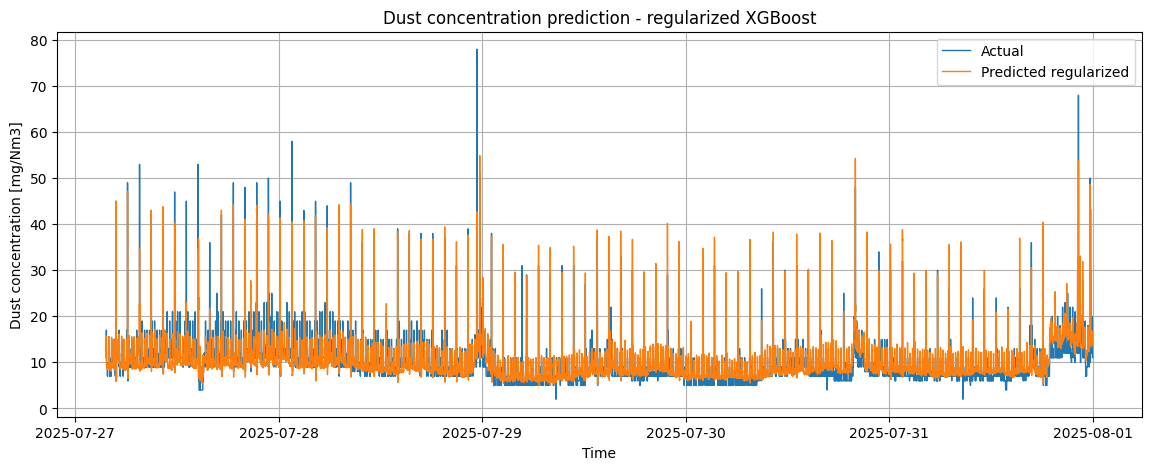

In [42]:
plt.figure(figsize=(14, 5))
plt.plot(y_test.index, y_test.values, label="Actual", linewidth=1)
plt.plot(y_test.index, y_pred_reg, label="Predicted regularized", linewidth=1)

plt.title("Dust concentration prediction - regularized XGBoost")
plt.xlabel("Time")
plt.ylabel("Dust concentration [mg/Nm3]")
plt.legend()
plt.grid(True)
plt.show()

In [43]:
results = pd.DataFrame([
    {
        "model": "baseline_previous",
        "features": "raw features",
        "MAE": 1.340,
        "R2": 0.660
    },
    {
        "model": "xgboost_full_fe",
        "features": "raw + lag + rolling + diff",
        "MAE": mae,
        "R2": r2
    },
    {
        "model": "xgboost_no_diff",
        "features": "raw + lag + rolling",
        "MAE": mae_no_diff,
        "R2": r2_no_diff
    },
    {
        "model": "xgboost_no_diff_1",
        "features": "raw + lag + rolling + diff_6/30/60",
        "MAE": mae_no_diff_1,
        "R2": r2_no_diff_1
    },
    {
        "model": "xgboost_regularized",
        "features": "raw + lag + rolling + diff, stronger regularization",
        "MAE": mae_reg,
        "R2": r2_reg
    }
])

results

,model,features,MAE,R2
0,baseline_previous,raw features,1.340000,0.660000
1,xgboost_full_fe,raw + lag + rolling + diff,1.393276,0.723417
2,xgboost_no_diff,raw + lag + rolling,1.451193,0.669893
3,xgboost_no_diff_1,raw + lag + rolling + diff_6/30/60,1.411626,0.713499
4,xgboost_regularized,"raw + lag + rolling + diff, stronger regulariz...",1.422567,0.711045


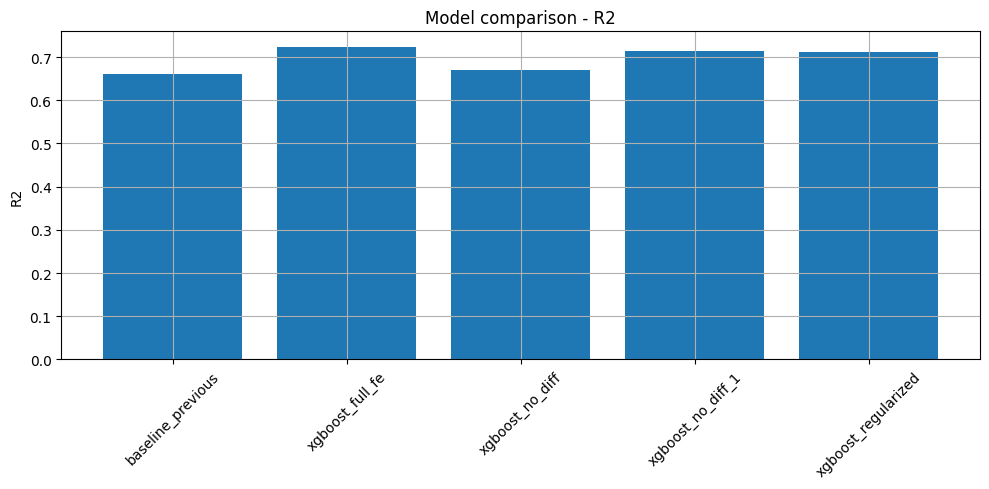

In [44]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(results["model"], results["R2"])
ax1.set_ylabel("R2")
ax1.set_title("Model comparison - R2")
ax1.tick_params(axis="x", rotation=45)
ax1.grid(True)

plt.tight_layout()
plt.show()

## 13. Porównanie wariantów modelu

W celu sprawdzenia wpływu poszczególnych grup cech wykonano kilka wariantów eksperymentu:

| Model | Cechy | MAE | R2 |
|---|---|---:|---:|
| baseline_previous | raw features | 1.340 | 0.660 |
| xgboost_full_fe | raw + lag + rolling + diff | 1.393 | 0.723 |
| xgboost_no_diff | raw + lag + rolling | 1.451 | 0.670 |
| xgboost_no_diff_1 | raw + lag + rolling + diff_6/30/60 | 1.412 | 0.713 |
| xgboost_regularized | pełny FE, mocniejsza regularyzacja | 1.423 | 0.711 |

Najlepszą wartość `R2` uzyskał model z pełnym zestawem cech po feature engineeringu. Usunięcie cech różnicowych pogorszyło wyniki, co potwierdza, że informacja o dynamice zmian procesu jest istotna dla predykcji stężenia pyłu.

In [46]:
eval_df = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_pred
}, index=y_test.index)

eval_df["error"] = eval_df["y_true"] - eval_df["y_pred"]
eval_df["abs_error"] = eval_df["error"].abs()

eval_df.head()

,y_true,y_pred,error,abs_error
timestamp,,,,
2025-07-27 03:40:40,11.0,11.323092,-0.323092,0.323092
2025-07-27 03:40:50,13.0,14.655911,-1.655911,1.655911
2025-07-27 03:41:00,13.0,15.740039,-2.740039,2.740039
2025-07-27 03:41:10,15.0,15.577614,-0.577614,0.577614
2025-07-27 03:41:20,15.0,14.262959,0.737041,0.737041


In [47]:
bins = [0, 10, 20, 40, np.inf]
labels = ["0-10", "10-20", "20-40", ">40"]

eval_df["dust_range"] = pd.cut(
    eval_df["y_true"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

range_metrics = (
    eval_df
    .groupby("dust_range", observed=True)
    .apply(lambda g: pd.Series({
        "n_samples": len(g),
        "mean_y_true": g["y_true"].mean(),
        "mean_y_pred": g["y_pred"].mean(),
        "MAE": mean_absolute_error(g["y_true"], g["y_pred"]),
        "RMSE": np.sqrt(np.mean((g["y_true"] - g["y_pred"]) ** 2)),
        "bias": (g["y_pred"] - g["y_true"]).mean(),
        "max_abs_error": g["abs_error"].max()
    }))
    .reset_index()
)

range_metrics

C:\Users\karol\AppData\Local\Temp\ipykernel_10544\414956060.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,dust_range,n_samples,mean_y_true,mean_y_pred,MAE,RMSE,bias,max_abs_error
0,0-10,28216.0,7.563049,8.095528,0.978832,1.404682,0.532478,28.263363
1,10-20,12879.0,12.501514,11.726056,2.002046,2.529330,-0.775459,16.532301
2,20-40,684.0,26.614035,23.989759,5.860162,7.351843,-2.624276,27.747503
3,>40,98.0,48.438776,40.318893,9.538828,13.791372,-8.119885,37.066522


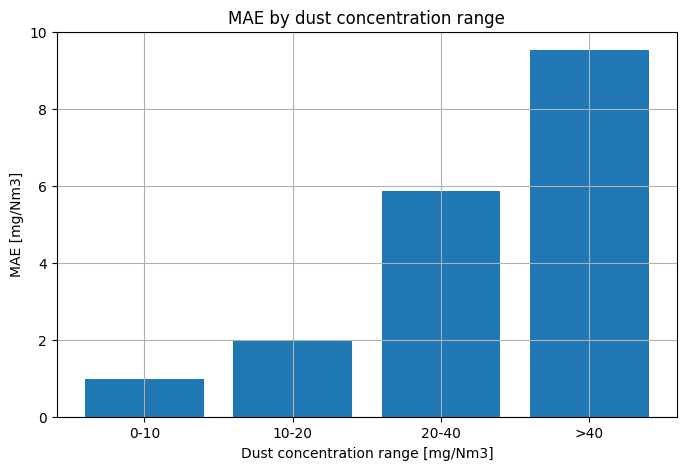

In [48]:
plt.figure(figsize=(8, 5))
plt.bar(range_metrics["dust_range"].astype(str), range_metrics["MAE"])
plt.title("MAE by dust concentration range")
plt.xlabel("Dust concentration range [mg/Nm3]")
plt.ylabel("MAE [mg/Nm3]")
plt.grid(True)
plt.show()

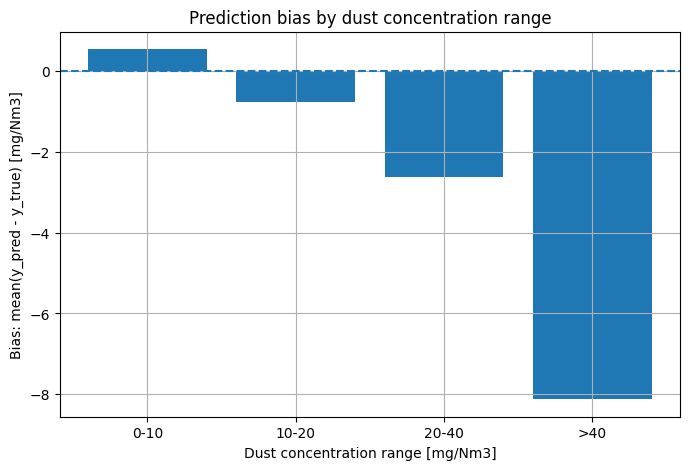

In [49]:
plt.figure(figsize=(8, 5))
plt.bar(range_metrics["dust_range"].astype(str), range_metrics["bias"])
plt.axhline(0, linestyle="--")
plt.title("Prediction bias by dust concentration range")
plt.xlabel("Dust concentration range [mg/Nm3]")
plt.ylabel("Bias: mean(y_pred - y_true) [mg/Nm3]")
plt.grid(True)
plt.show()

## 14. Ocena modelu w zależności od zakresu stężenia pyłu

Model oceniono osobno dla różnych zakresów wartości rzeczywistego stężenia pyłu:

| Zakres pyłu [mg/Nm3] | Liczba próbek | MAE | Bias |
|---|---:|---:|---:|
| 0–10 | 28216 | 0.979 | +0.532 |
| 10–20 | 12879 | 2.002 | -0.775 |
| 20–40 | 684 | 5.860 | -2.624 |
| >40 | 98 | 9.539 | -8.120 |

Analiza wykazała, że model bardzo dobrze odwzorowuje normalny zakres pracy elektrofiltru, szczególnie dla stężenia pyłu poniżej 10 mg/Nm3. Dla wyższych zakresów pyłu błąd rośnie, a model wykazuje tendencję do niedoszacowania wartości rzeczywistych.

Jest to prawdopodobnie związane z silnie niezrównoważonym rozkładem zmiennej docelowej oraz z charakterem wysokich pików pyłu. Krótkotrwałe epizody podwyższonego zapylenia mogą być generowane przez pracę strzepywaczy i mieć częściowo losową amplitudę, której nie da się jednoznacznie przewidzieć na podstawie dostępnych sygnałów procesowych.

In [50]:
FEATURE_ENGINEERED_PATH = DATA_PROCESSED / "df_feature_engineered_v1.parquet"

df_fe_clean.to_parquet(FEATURE_ENGINEERED_PATH)

print(FEATURE_ENGINEERED_PATH)
print(df_fe_clean.shape)

c:\Users\karol\Desktop\esp_industrial_ml\data\processed\df_feature_engineered_v1.parquet
(209384, 1166)


In [51]:
X_PATH = DATA_PROCESSED / "X_feature_engineered_v1.parquet"
Y_PATH = DATA_PROCESSED / "y_feature_engineered_v1.parquet"

X.to_parquet(X_PATH)
y.to_frame(name=target_col).to_parquet(Y_PATH)

print(X_PATH, X.shape)
print(Y_PATH, y.shape)

c:\Users\karol\Desktop\esp_industrial_ml\data\processed\X_feature_engineered_v1.parquet (209384, 1164)
c:\Users\karol\Desktop\esp_industrial_ml\data\processed\y_feature_engineered_v1.parquet (209384,)


In [52]:
RESULTS_PATH = DATA_PROCESSED / "model_results_feature_engineering_v1.csv"

results.to_csv(RESULTS_PATH, index=False)

print(RESULTS_PATH)

c:\Users\karol\Desktop\esp_industrial_ml\data\processed\model_results_feature_engineering_v1.csv


In [53]:
FEATURE_LIST_PATH = DATA_PROCESSED / "feature_list_v1.csv"

feature_list = pd.DataFrame({
    "feature": X.columns
})

feature_list.to_csv(FEATURE_LIST_PATH, index=False)

print(FEATURE_LIST_PATH)
print(feature_list.shape)

c:\Users\karol\Desktop\esp_industrial_ml\data\processed\feature_list_v1.csv
(1164, 1)


## 15. Wnioski z eksperymentu feature engineering V1

Przeprowadzony feature engineering potwierdził, że uwzględnienie historii i dynamiki sygnałów procesowych poprawia jakość predykcji stężenia pyłu, szczególnie pod względem wyjaśnianej zmienności procesu (`R2`).

Najważniejsze wnioski:

1. Model po feature engineeringu osiągnął `R2 = 0.723`, względem `R2 = 0.660` dla wcześniejszego modelu bazowego.
2. Największe znaczenie miały cechy związane z prądami, mocą i napięciami zespołów WN, temperaturami w obrębie instalacji oraz obciążeniem kotła.
3. Cechy dynamiczne, szczególnie `diff_6`, miały bardzo istotny wpływ na predykcję, co potwierdza dynamiczny charakter procesu odpylania.
4. Model dobrze przewiduje normalny zakres pracy elektrofiltru, ale gorzej radzi sobie z rzadkimi pikami wysokiego zapylenia.
5. Wysokie piki pyłu mogą być powiązane z pracą strzepywaczy i mieć częściowo losową amplitudę, dlatego ich dokładna predykcja punktowa może być ograniczona.
6. Dla dalszych prac wskazane jest rozdzielenie problemu na:
   - predykcję bazowego poziomu pyłu,
   - ocenę ryzyka wystąpienia epizodów emisyjnych,
   - analizę wpływu strzepywaczy na prawdopodobieństwo pików pyłu.

Kolejnym etapem będzie analiza zależności pomiędzy aktywnością strzepywaczy a występowaniem krótkotrwałych pików stężenia pyłu.